Initialising PySpark

In [99]:
# install pyspark

!pip3 install pyspark

In [100]:
# install libraries

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# initialise SparkSession

spark = SparkSession.builder \
                    .appName("LinearRegression_spark") \
                    .master("local[*]") \
                    .config("spark.executor.memory", "4g") \
                    .config("spark.driver.memory", "2g") \
                    .config("spark.executor.cores", "2") \
                    .config("spark.sql.inMemoryColumnarStorage.compressed", "true") \
                    .getOrCreate()


spark

In [101]:
print(f"Spark UI available at: {spark.sparkContext.uiWebUrl}")

Spark UI available at: http://1d632fc3488f:4040


In [102]:
spark.sparkContext.setLogLevel("INFO")

In [103]:
# find the memory usage

import psutil

print(f"CPU Usage: {psutil.cpu_percent()}%")

print(f"Memory Usage: {psutil.virtual_memory().percent}%")

CPU Usage: 19.6%
Memory Usage: 16.2%


In [104]:
# load dataset from Google Drive

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:
# import file titled Property from my Google Drive

df = spark.read.csv("/content/drive/MyDrive/CN7030 - Machine Learning on Big Data (T2)/Labs/Week 3 Lab - Linear Regression Modelling - Wednesday 18th February - Complete/property.csv", header=True, inferSchema=True)

In [115]:
# show dataset

df.show(10)

+--------------+------------+-------------+----------+--------+------------------+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|             Price|
+--------------+------------+-------------+----------+--------+------------------+
|          1360|           2|            3|      1953|    7860| 303948.1373854071|
|          4272|           3|            3|      1997|    5292| 860386.2685075302|
|          3592|           4|            1|      1983|    9723| 734389.7538956215|
|           966|           6|            1|      1903|    4086| 226448.8070714377|
|          4926|           6|            4|      1944|    1081|1022486.2616704078|
|          3944|           6|            2|      1938|    3542| 845638.1354384426|
|          3671|           2|            1|      1963|    5105| 748779.2192281872|
|          3419|           4|            2|      1925|    5448| 743007.2614135538|
|           630|           2|            2|      2012|    3204| 135656.4528785377|
|   

In [116]:
# show schema

df.printSchema()

root
 |-- Square_Footage: integer (nullable = true)
 |-- Num_Bedrooms: integer (nullable = true)
 |-- Num_Bathrooms: integer (nullable = true)
 |-- Year_Built: integer (nullable = true)
 |-- Lot_Size: integer (nullable = true)
 |-- Price: double (nullable = true)



In [117]:
# number of rows

print("Total Records",df.count())

Total Records 1000000


In [118]:
print("Total Partitions ",df.rdd.getNumPartitions())

Total Partitions  2


In [119]:
# statistical analysis

df.describe().show()

+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|summary|   Square_Footage|     Num_Bedrooms|     Num_Bathrooms|       Year_Built|         Lot_Size|             Price|
+-------+-----------------+-----------------+------------------+-----------------+-----------------+------------------+
|  count|          1000000|          1000000|           1000000|          1000000|          1000000|           1000000|
|   mean|      2750.657104|         3.501114|          2.500439|       1960.52736|      5502.373911| 581839.6653163614|
| stddev|1298.569362387213|1.708173784151257|1.1178528780094728|35.21780350510348|2598.885882999355|260685.36722644986|
|    min|              500|                1|                 1|             1900|             1000| 51495.71116919513|
|    max|             4999|                6|                 4|             2021|             9999|1123219.4691521737|
+-------+-----------------+-------------

In [120]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")

CPU Usage after openig the csv file: 27.1%


In [121]:
print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

Memory Usage after csv file: 19.2%


Check missing or null values for each column

In [122]:
# check missing or null values for each column

from pyspark.sql.functions import col,isnan, when, count

df.select([count(when(isnan(c) | col(c).isNull(), c))
.alias(c) for c in df.columns]).show()

+--------------+------------+-------------+----------+--------+-----+
|Square_Footage|Num_Bedrooms|Num_Bathrooms|Year_Built|Lot_Size|Price|
+--------------+------------+-------------+----------+--------+-----+
|             0|           0|            0|         0|       0|    0|
+--------------+------------+-------------+----------+--------+-----+



## Creating the first linear regression model

In [123]:
# convert all columns into Spark feature vectors

from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols = ["Square_Footage", "Num_Bedrooms", "Num_Bathrooms","Year_Built","Lot_Size"],
                            outputCol= "Features")

In [124]:
# scale features

scaler = StandardScaler(inputCol = "Features",
                        outputCol = "scaled_Features")

In [125]:
# create linear regression model

regressor = LinearRegression(labelCol = 'Price',
                             featuresCol = 'scaled_Features')

In [126]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")

print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 95.9%
Memory Usage after csv file: 19.2%


In [127]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler

pipeline = Pipeline(stages = [assembler, scaler, regressor])

# saving the pipeline

pipeline.write().overwrite().save("pipeline_LRsaved_model")

In [128]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")

print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 100.0%
Memory Usage after csv file: 19.5%


In [129]:
# loading the pipeline

pipelineModel = Pipeline.load('./pipeline_LRsaved_model')

Splitting the data

In [130]:
# split the dataset into training and testing

# 80% training data and 20% testing data

data_train , data_test = df.randomSplit([0.8, 0.2], seed = 42)

Training the pipeline

In [131]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")

print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 100.0%
Memory Usage after csv file: 19.5%


In [132]:
Model = pipelineModel.fit(data_train)

In [133]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")

print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 97.6%
Memory Usage after csv file: 22.3%


In [134]:
print("total LR cofficents",len(Model.stages[2].coefficients) )

print("Cofficientents",Model.stages[2].coefficients)

print("Intecept",Model.stages[2].intercept)

total LR cofficents 5
Cofficientents [259780.12595993132,8525.61965929261,3383.3476584054356,-3505.6317693204455,271.5939763709452]
Intecept 201303.7713575292


In [135]:
# testing our model on unseen data

pred = Model.transform(data_test)

pred.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118059.1392256782 |117632.63219959654|
|109776.33782739218|106670.25438504865|
|122744.64022799424|129488.84657892359|
|114407.05613097842|115218.14440379351|
|124296.11676457041|103211.80851419755|
|121766.15789057045|95443.54011673816 |
|114882.94170202375|75029.23686169085 |
|123959.45591767188|102503.11714851807|
|127377.38339111503|146356.05433151638|
|127104.05273631949|121454.94973331907|
+------------------+------------------+
only showing top 10 rows


Creating the linear regression model

In [136]:
# #create the linear regression model

lassoregressor = LinearRegression(labelCol = 'Price',
                                  featuresCol = 'scaled_Features',
                                  regParam = 0.5,
                                  elasticNetParam = 0.8)

In [137]:
# pipeline

lassopipeline = Pipeline(stages = [assembler, scaler, lassoregressor])

lassomodel = lassopipeline.fit(data_train)

In [138]:
print(f"CPU Usage after openig the csv file: {psutil.cpu_percent()}%")

print(f"Memory Usage after csv file: {psutil.virtual_memory().percent}%")

CPU Usage after openig the csv file: 94.5%
Memory Usage after csv file: 21.6%


In [139]:
# testing the model on unseen data

lassoprediction = lassomodel.transform(data_test)

lassoprediction.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118061.09963261818|117632.63219959654|
|109779.13669853474|106670.25438504865|
|122746.23245008124|129488.84657892359|
|114409.60840190266|115218.14440379351|
|124297.53535481314|103211.80851419755|
|121767.07113485641|95443.54011673816 |
|114885.46878136987|75029.23686169085 |
|123960.1967116958 |102503.11714851807|
|127378.26900910235|146356.05433151638|
|127105.20477890555|121454.94973331907|
+------------------+------------------+
only showing top 10 rows


In [140]:
ridgeregressor = LinearRegression(labelCol = 'Price',
                                  featuresCol = 'scaled_Features',
                                  regParam = 0.5,
                                  elasticNetParam = 0.8)

In [141]:
ridgepipeline = Pipeline(stages = [assembler, scaler, ridgeregressor])

ridgemodel = ridgepipeline.fit(data_train)

In [142]:
ridgeprediction = ridgemodel.transform(data_test)

ridgeprediction.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118061.09963261818|117632.63219959654|
|109779.13669853474|106670.25438504865|
|122746.23245008124|129488.84657892359|
|114409.60840190266|115218.14440379351|
|124297.53535481314|103211.80851419755|
|121767.07113485641|95443.54011673816 |
|114885.46878136987|75029.23686169085 |
|123960.1967116958 |102503.11714851807|
|127378.26900910235|146356.05433151638|
|127105.20477890555|121454.94973331907|
+------------------+------------------+
only showing top 10 rows


In [143]:
# evaluate the model with regression and classification tasks

from pyspark.ml.evaluation import RegressionEvaluator
evaluator_mse = RegressionEvaluator(labelCol =
                                    'Price',
                                    predictionCol =
                                    'prediction',
                                    metricName =
                                    'mse')

# calculate MSE

mse1 = evaluator_mse.evaluate(pred)
mselasso = evaluator_mse.evaluate(lassoprediction)
mseridge = evaluator_mse.evaluate(ridgeprediction)

evaluator_rmse = RegressionEvaluator(labelCol =
                                     'Price',
                                     predictionCol =
                                     'prediction',
                                     metricName =
                                     'rmse')

# calculate RMSE

rmse1 = evaluator_rmse.evaluate(pred)
rmse2_lasso = evaluator_rmse.evaluate(lassoprediction)
rmse3Ridge = evaluator_rmse.evaluate(ridgeprediction)

evaluator_r2 = RegressionEvaluator(labelCol = 'Price',
                                   predictionCol = 'prediction',
                                   metricName = 'r2')

# calculate R_squared

r2_score1 = evaluator_r2.evaluate(pred)
r2_lasso = evaluator_r2.evaluate(lassoprediction)
r2_ridge = evaluator_r2.evaluate(ridgeprediction)

# print the evaluation metrics

print('Regression - MSE: ', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_score1)

print('Lasso - MSE: ', mselasso, ', RMSE: ', rmse2_lasso, ', R^2: ', r2_lasso)

print('Ridge - MSE: ', mseridge, ', RMSE: ', rmse3Ridge, ', R^2: ', r2_ridge)

Regression - MSE:  400269383.4208196 , RMSE:  20006.733452036082 , R^2:  0.9940979930679152
Lasso - MSE:  400269400.8460965 , RMSE:  20006.733887521383 , R^2:  0.994097992810978
Ridge - MSE:  400269400.8460965 , RMSE:  20006.733887521383 , R^2:  0.994097992810978


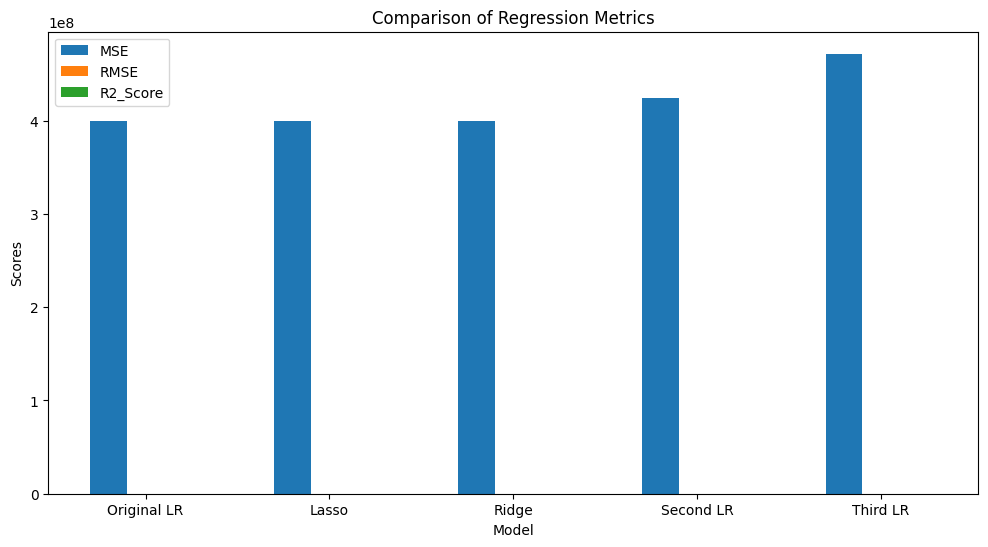

In [144]:
import matplotlib.pyplot as plt
import numpy as np

mse = [mse1, mselasso, mseridge, mse_new, mse_third]
rmse = [rmse1, rmse2_lasso, rmse3Ridge, rmse_new, rmse_third]
r2_score = [r2_score1, r2_lasso, r2_ridge, r2_score_new, r2_score_third]

positions = np.arange(len(mse))
bar_width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(positions - bar_width, mse, width = bar_width, label = 'MSE')
plt.bar(positions, rmse, width = bar_width, label = 'RMSE')
plt.bar(positions + bar_width, r2_score, width = bar_width, label = 'R2_Score')

# adding labels and title

plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Comparison of Regression Metrics')

# adding the legend

plt.legend()
plt.xticks(positions, ['Original LR', 'Lasso', 'Ridge', 'Second LR', 'Third LR'])
plt.show()

Analysis for the Best Performing Linear Regression Model

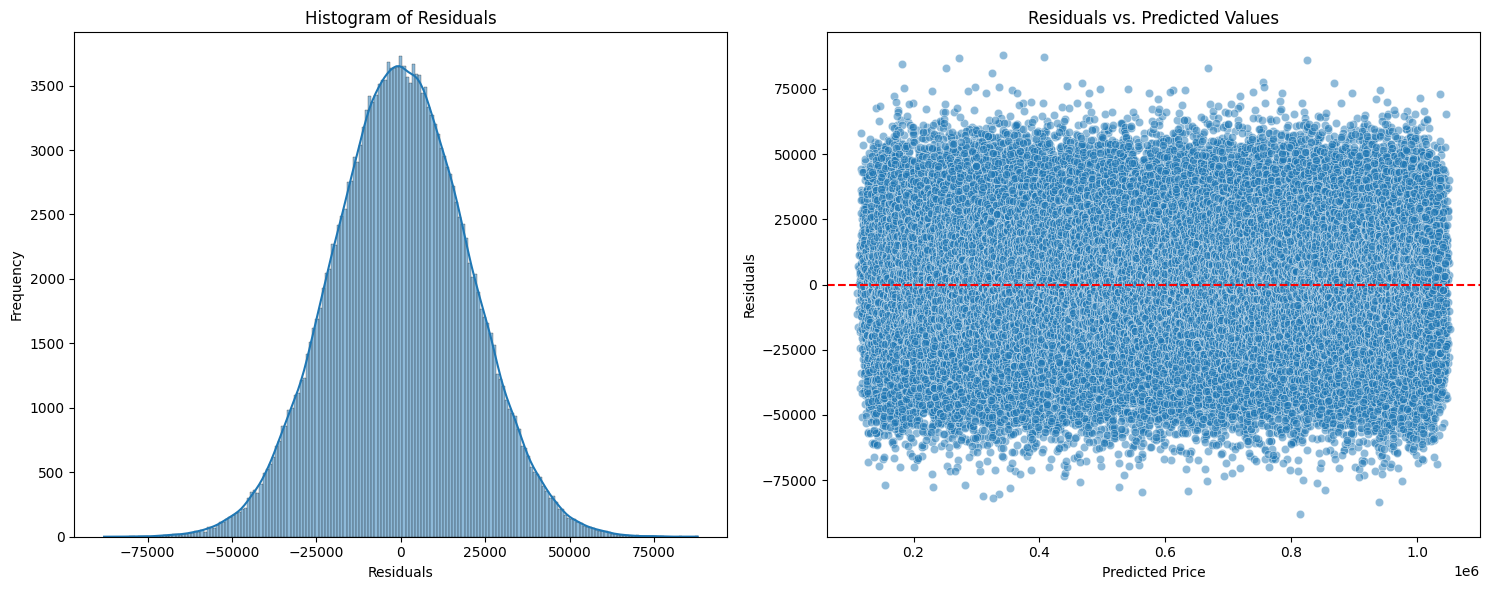

In [145]:
import seaborn as sns
import matplotlib.pyplot as plt

predictions_and_actuals = pred.select('prediction', 'Price').toPandas()

# calculate residuals
predictions_and_actuals['residuals'] = predictions_and_actuals['Price'] - predictions_and_actuals['prediction']

# plot histogram of residuals
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.histplot(predictions_and_actuals['residuals'], kde=True, ax=axes[0])
axes[0].set_title('Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# plot scattergraph of residuals vs. predicted values
sns.scatterplot(x='prediction', y='residuals', data=predictions_and_actuals, ax=axes[1], alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## Second linear regression model with different feature combination

In [146]:
# create a new VectorAssembler with a different set of input features

# exclude the columns 'Year_Built' and 'Num_Bathrooms'
assembler_new = VectorAssembler(inputCols = ["Square_Footage", "Num_Bedrooms", "Lot_Size"],
                               outputCol= "Features_new")

In [147]:
# create a new StandardScaler for the new combination of features

new_StandardScaler = StandardScaler(inputCol = "Features_new",
                            outputCol = "new_scaled_Features")

In [148]:
# create a new Linear Regression model

regressor_new = LinearRegression(labelCol = 'Price',
                               featuresCol = 'new_scaled_Features')

In [149]:
# create a new pipeline with the new assembler, scaler, and regressor

pipeline_new = Pipeline(stages = [assembler_new, new_StandardScaler, regressor_new])

# train the new pipeline model

model_new = pipeline_new.fit(data_train)

In [150]:
# make predictions using the new model

pred_new = model_new.transform(data_test)

pred_new.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|118959.29585731945|117632.63219959654|
|119040.98148116827|106670.25438504865|
|118825.50406877325|129488.84657892359|
|118812.76700629167|115218.14440379351|
|118805.39845774861|103211.80851419755|
|124660.13010648242|95443.54011673816 |
|124045.27736305338|75029.23686169085 |
|124584.44458644724|102503.11714851807|
|124176.75332205747|146356.05433151638|
|124001.69766167011|121454.94973331907|
+------------------+------------------+
only showing top 10 rows


In [151]:
# evaluate the model

# calculate MSE
mse_new = evaluator_mse.evaluate(pred_new)

# calculate RMSE
rmse_new = evaluator_rmse.evaluate(pred_new)

# calculate R-squared
r2_score_new = evaluator_r2.evaluate(pred_new)

# print the evaluation metrics

print('Second Linear Regression Model - MSE:', mse1, ', RMSE: ', rmse1, ', R^2: ', r2_score1)

Second Linear Regression Model - MSE: 400269383.4208196 , RMSE:  20006.733452036082 , R^2:  0.9940979930679152


Analysis for Second Linear Regression Model

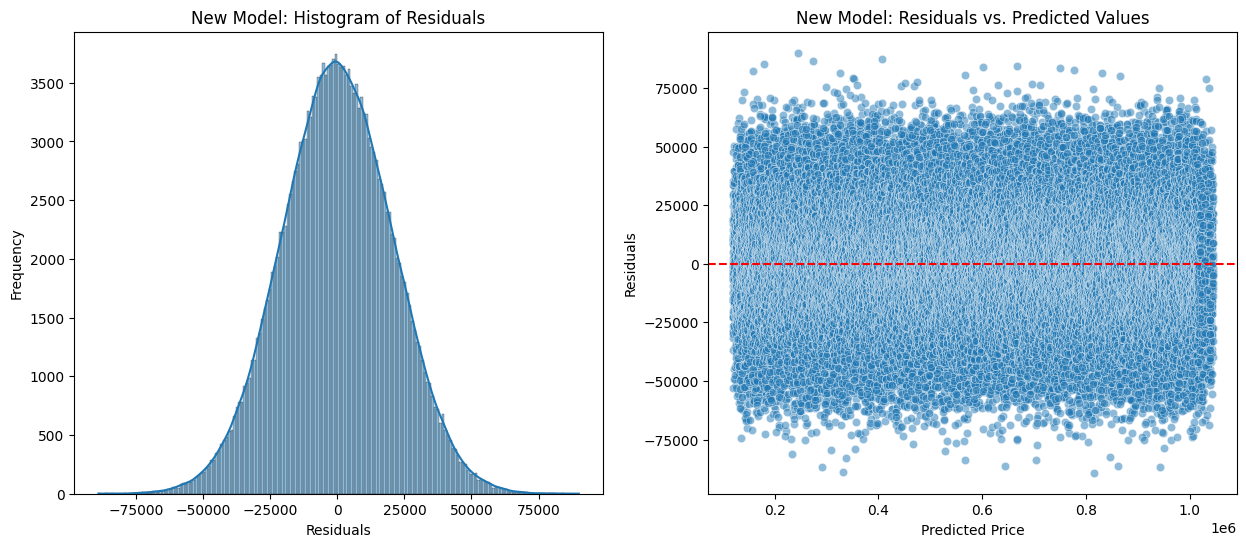

In [152]:
import seaborn as sns
import matplotlib.pyplot as plt

# # calculate residuals for the second model
predictions_and_actuals_new = pred_new.select('prediction', 'Price').toPandas()
predictions_and_actuals_new['residuals'] = predictions_and_actuals_new['Price'] - predictions_and_actuals_new['prediction']

# plot scattergraph of residuals vs. predicted values
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#plot histogram

sns.histplot(predictions_and_actuals_new['residuals'], kde=True, ax=axes[0])
axes[0].set_title('New Model: Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')


# # plot scattergraph of residuals vs. predicted values for the second model
sns.scatterplot(x='prediction', y='residuals', data=predictions_and_actuals_new, ax=axes[1], alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('New Model: Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')

plt.show()

## Third linear regression model with different feature combination

In [153]:
# create a new VectorAssembler for the third model with a different set of input features

# using columns 'Square_Footage', 'Num_Bathrooms', and 'Year_Built'
assembler_third = VectorAssembler(inputCols = ["Square_Footage", "Num_Bathrooms", "Year_Built"],
                                outputCol= "Features_third")

In [154]:
# create a new StandardScaler for the third combination of features

scaler_third = StandardScaler(inputCol = "Features_third",
                            outputCol = "scaled_Features_third")

In [155]:
# create a new Linear Regression model for the third combination

regressor_third = LinearRegression(labelCol = 'Price',
                               featuresCol = 'scaled_Features_third')

In [156]:
# create a new pipeline for the third model

pipeline_third = Pipeline(stages = [assembler_third, scaler_third, regressor_third])

# train the third pipeline model
model_third = pipeline_third.fit(data_train)

In [157]:
# make predictions using the third model
pred_third = model_third.transform(data_test)

# show predictions
pred_third.select('prediction', 'Price').show(10, truncate = False)

+------------------+------------------+
|prediction        |Price             |
+------------------+------------------+
|130802.82477590335|117632.63219959654|
|122437.58960178054|106670.25438504865|
|135610.02604922635|129488.84657892359|
|127271.85776321347|115218.14440379351|
|137157.95182082528|103211.80851419755|
|128811.10211539794|95443.54011673816 |
|122537.17573480583|75029.23686169085 |
|131056.1308181738 |102503.11714851807|
|134867.47076124407|146356.05433151638|
|134767.88462821877|121454.94973331907|
+------------------+------------------+
only showing top 10 rows


In [158]:
# evaluate the third model with regression metrics

# calculate MSE
mse_third = evaluator_mse.evaluate(pred_third)

# calculate RMSE
rmse_third = evaluator_rmse.evaluate(pred_third)

# calculate R-2
r2_score_third = evaluator_r2.evaluate(pred_third)

# print the evaluation metrics
print('Third Linear Regression Model - MSE: ', mse_third, ', RMSE: ', rmse_third, ', R^2: ', r2_score_third)

Third Linear Regression Model - MSE:  471942963.59983695 , RMSE:  21724.248286185575 , R^2:  0.9930411598836015


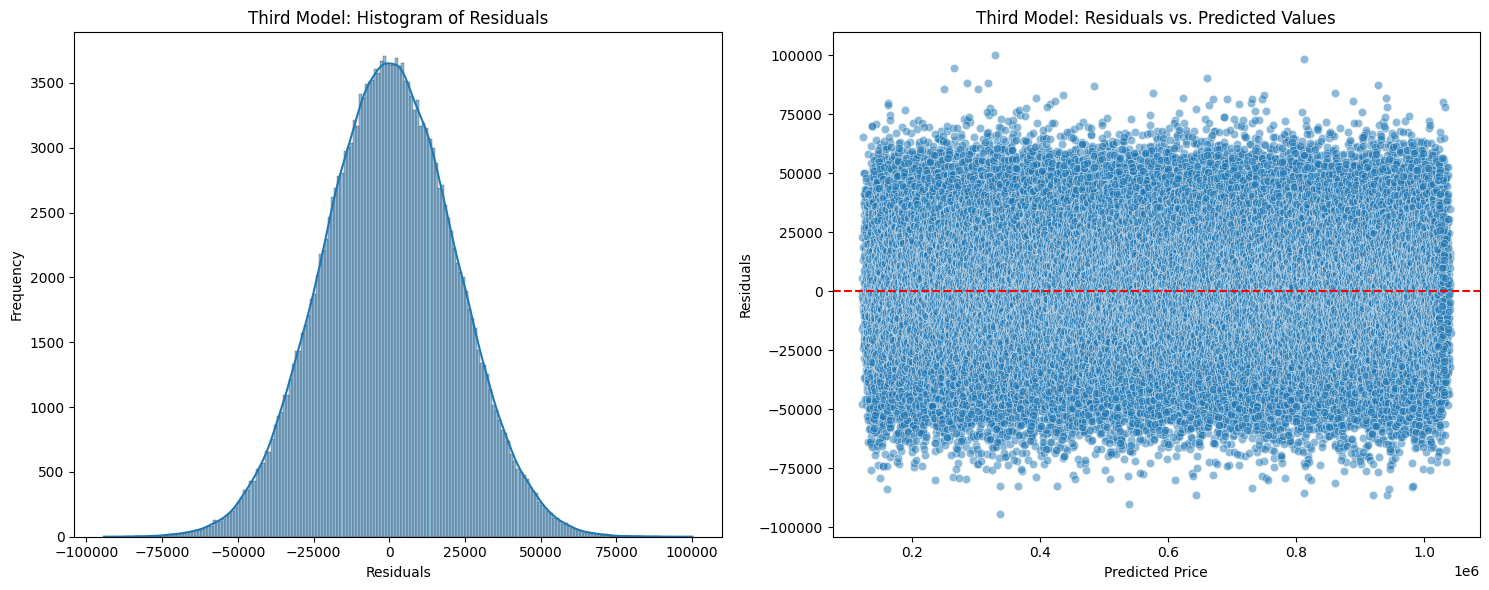

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt

# calculate residuals for the third model
predictions_and_actuals_third = pred_third.select('prediction', 'Price').toPandas()
predictions_and_actuals_third['residuals'] = predictions_and_actuals_third['Price'] - predictions_and_actuals_third['prediction']

# plot scattergraph of residuals vs. predicted values
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# plot histogram
sns.histplot(predictions_and_actuals_third['residuals'], kde=True, ax=axes[0])
axes[0].set_title('Third Model: Histogram of Residuals')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# plot scattergraph of residuals vs. predicted values for the third model
sns.scatterplot(x='prediction', y='residuals', data=predictions_and_actuals_third, ax=axes[1], alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Third Model: Residuals vs. Predicted Values')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## R-squared Comparison of All Models

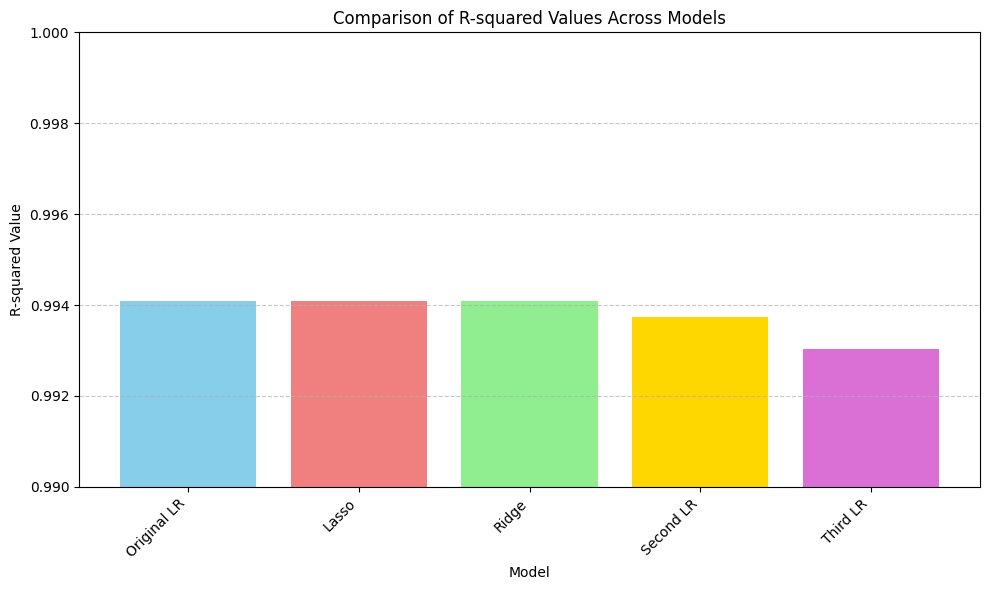

In [160]:
import matplotlib.pyplot as plt
import numpy as np

# R-squared values
r2_values = [r2_score1, r2_lasso, r2_ridge, r2_score_new, r2_score_third]
model_names = ['Original LR', 'Lasso', 'Ridge', 'Second LR', 'Third LR']

# create positions for the bars
positions = np.arange(len(model_names))

plt.figure(figsize=(10, 6))
plt.bar(positions, r2_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orchid'])

# add labels and title
plt.xlabel('Model')
plt.ylabel('R-squared Value')
plt.title('Comparison of R-squared Values Across Models')
plt.xticks(positions, model_names, rotation=45, ha='right') # Rotate labels for better readability
plt.ylim(0.99, 1.0) # Set y-axis limits to better show differences in high R-squared values
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Summary

This exercise involved building, comparing, and analysing several linear regression models using PySpark to predict property prices based on various feature combinations.

### **R-squared values for each model:**


First Linear Regression Model: 0.9941


Lasso Model: 0.9941


Ridge Model: 0.9941


Second Linear Regression Model: 0.9937


Third Linear Regression Model: 0.9930

### **Choices for Feature Selection:**

For the First Linear Regression, Lasso and Ridge models, I used all five available features: ‘Square_Footage’, ‘Num_Bedrooms’, ‘Num_Bathrooms’, ‘Year_Built’, and ‘Lot_Size’. The rationale was to establish a baseline performance with a comprehensive set of potentially relevant predictors.



For the Second Linear Regression Model, I used only ‘Square_Footage’, ‘Num_Bedrooms’, and ‘Lot_Size’. This was to investigate whether a simpler model with fewer features, focusing on core property size and land size, could still maintain high accuracy while reducing complexity.



For the Third Linear Regression Model, I used ‘Square_Footage’, ‘Num_Bathrooms’, and ‘Year_Built’. This aimed to test the impact of architectural and age-related features alongside property size, without considering the number of rooms or land area.

### **Observations from Model Comparisons:**

The models that utilised all five features (the First Linear Regression, Lasso, and Ridge models) had the best performance. They achieved an R-squared of approximately 0.994 and an RMSE of around $20,000, indicating an extremely strong fit to the data and highly accurate predictions.



The Second and Third Linear Regression Models, which were trained on reduced features, experienced a slight drop in performance.  This  demonstrates that the omitted features in these reduced datasets were  valuable contributors to the model's predictive power.

### **Challenges Faced and How They Were Resolved:**

There was a lot of human error on my part. A key challenge I encountered was an IllegalArgumentException during the implementation of the Second and Third Linear Regression Models. This is because my variable names were incorrectly typed . This was successfully resolved by carefully identifying and correcting inconsistent variable names.

### **Insights Gained from This Exercise:**

This week’s lab strongly emphasised the importance of well-chosen features in predictive modelling. Even highly correlated features, when removed, can lead to a measurable decrease in model performance.